# Lab 6
You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against *n* computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it.

A few requirements:
- The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
- Players should have chips.
- Dealer's actions are predefined by rules of the game (typically hit on 16).
- The players should be aware of all shown cards so that they can count cards.
- Each player could have a different strategy.
- The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

https://www.wikihow.com/Sample/Blackjack-Rules

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [74]:
### initial answer

class Card:
    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank
        
class Deck:
    def __init__(self, num_decks):
        
        ranks = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K', 'A']
        suits = ['Heart', 'Diamond', 'Club', 'Spade']

        self.cards = []


## Must follow deck -> suit -> rank
        for deck in range(num_decks):
            for suit in suits:
                for rank in ranks:
                    card = Card(suit, rank)
                    self.cards.append(card)
                    
        # "That's not any of the given ranks/ suits... shuffle!"
        self.plastic_card = Card("Plastic", "Plastic")

    def insert_plastic_card_randomly(self):
        position = np.random.randint(0, len(self.cards) +1)

        self.cards.insert(position, self.plastic_card)

    def shuffle(self):
## https://www.wscubetech.com/resources/python/programs/shuffle-card
        
        deck_indices = np.random.permutation(len(self.cards))  
        self.cards = [self.cards[i] for i in deck_indices]

    def draw(self):
        ## Removes and returns the first 0th item
        card = self.cards.pop(0)

        if card is self.plastic_card:
            print("Plastic card. Shuffling deck.")
            self.shuffle()
            self.insert_plastic_card_randomly()

        return card

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook.

In [75]:
## okay
## added as pdf in file

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [76]:
class Hand:
    def __init__(self):

    # add cards to hand
    def add_card(self, card):  

    # calculate 
    def calculate_value(self):
        # do something about ace adjustment

class Strategy:
    ## could just be like always fold, always hit, 

class Player:
    def __init__(self):

    # deck needs to be passed in
    def hit(self, deck):

    def play(self, deck, dealer_card, game):
        

class Dealer:
    def __init__(self):

    def play(self, deck, game):

class Game:
    def __init__(self, deck, players, dealer):

    def count(self, card):

    def deal_card(self, hand):


    def start_game(self):
        ## if player is out of chips they can't play
        ## pay to play cost is 2?

class Chips():
    def __init__(self, initial_amount=100):

    def pay_to_play(self, game):

    def win(self):

    def lose(self):

IndentationError: expected an indented block after function definition on line 2 (3624508882.py, line 5)

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [77]:
## initial answer
class Hand:
    def __init__(self):
        self.cards = []
        
    # add cards to hand
    def add_card(self, card):
        self.cards.append(card)

    # calculate 
    ## stack exchange example
    def calculate_value(self):
        value = 0
        aces = 0

        for card in self.cards:
            if card.rank == "Plastic":
                continue 
                
            if card.rank in ["K", "Q", "J"]:
                value += 10

            elif card.rank == "A":
                value += 11
                aces += 1


            else:
                value += int(card.rank)

        # originally had this but replaced after debugging with chatgpt
 ##       if ace and value <= 11:
         #   value += 10
        # because only adjusting once, may require adjusting multiple aces.

        while value > 21 and aces > 0:
            # backward correction
            value -= 10
            aces -= 1
            
        return value

class Strategy:
    def always_hit(self, hand_value, dealer_card):
        return "hit"

    def always_fold(self, hand_value, dealer_card):
        return "fold"

    def basic_strat(self, hand_value, dealer_card):
        return "hit" if hand_value < 17 else "fold"

class Chip:
    def __init__(self, initial_amount = 100):
        self.balance = initial_amount

    def pay_to_play(self):
        return self.balance >= 2

    def win(self):
        self.balance += 4

    def lose(self):
        self.balance -= 2

    def push(self):
        pass



class Player:
    def __init__(self, name, strat, chips = 100):
        self.name = name
        self.hand = Hand() 
        self.strat = strat
        self.chips = Chip(chips)

    # deck needs to be passed in
    def hit(self, deck, game):
        card = deck.draw()
        # draw a card and add to hand
        self.hand.add_card(card)

        game.seen_cards.append(card)
        game.update_count(card)

    def play(self, deck, dealer_card, game):
        while True:
            value = self.hand.calculate_value()
            action = self.strat(value, dealer_card)

            if action == "hit":
                self.hit(deck, game)
                if self.hand.calculate_value() > 21:
                    break

            else:
                break

class Dealer:
    def __init__(self):
        self.hand = Hand()
        

    # debugged by chat was just def play (self, deck) before
    def play(self, deck, game):
        # while the hand's calculated value is less than 17, draw a card and add the card
        while self.hand.calculate_value() < 17:
            card = deck.draw()
            self.hand.add_card(card)
            game.seen_cards.append(card)
            game.update_count(card)

class Game:
    def __init__(self, deck, players, dealer):
        self.deck = deck
        self.players = players
        self.dealer = dealer

        self.seen_cards = []
        self.running_count = 0

    ## added later after using gpt
    def update_count(self, card):
        rank = card.rank
        if rank in ['2', '3','4','5','6']:
            self.running_count += 1
        elif rank in ['10','J','Q','K','A']:
            self.running_count -= 1

    def deal_card(self, hand):
        card = self.deck.draw()
        hand.add_card(card)
        self.visible_cards.append(card)
        self.update_count(card)


    def start_game(self):
        # reset cards
        for p in self.players:
            p.hand = Hand()
        self.dealer.hand = Hand()

        #can you play? do you have enough money?
        can_you_play = [p for p in self.players if p.chips.pay_to_play()]

        if not can_you_play:
            # NO ONE CAN PLAY
            return
            
        # deal 2 initial cards
        for i in range(2):
            # gpt debugged. did not exist in initial code
            for p in can_you_play:
                p.hit(self.deck, self)
            card = self.deck.draw()
            self.dealer.hand.add_card(card)
            self.seen_cards.append(card)
            self.update_count(card)
            

        # dealer's card that players can see 
        dealer_upcard = self.dealer.hand.cards[0]

        dealer_value = self.dealer.hand.calculate_value()

        for p in can_you_play:
            # initially had this but changed after getting errors
#            p.play(self.deck, dealer_upcard, self)

#        self.dealer.play(self.deck, self)

            player_value = p.hand.calculate_value()


            if player_value > 21:
                p.chips.lose()

            elif dealer_value > 21 or player_value > dealer_value:
                p.chips.win()

            elif player_value < dealer_value:
                p.chips.lose()

            else:
                p.chips.push()

5. Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [78]:

deck = Deck(6)
deck.shuffle()
deck.insert_plastic_card_randomly()

strategy = Strategy()

players = [ Player("I_always_hit", strategy.always_hit),
  Player("I_always_fold", strategy.always_fold),
  Player("I'm just doing my thing!", strategy.basic_strat)]

dealer = Dealer()
game = Game(deck, players, dealer)

rounds = 3

for i in range(rounds):
    game.start_game()

    # got help from chatgpt. didn't understand how to express it
    # print each player's hand and chip
    for p in players:
        print(p.name)
        print("  Hand:", [(c.rank, c.suit) for c in p.hand.cards])
        print("  Value:", p.hand.calculate_value())
        print("  Chips:", p.chips.balance)

    print("Dealer Hand:", [(c.rank, c.suit) for c in dealer.hand.cards])
    print("Dealer Value:", dealer.hand.calculate_value())

I_always_hit
  Hand: [('5', 'Diamond'), ('3', 'Spade')]
  Value: 8
  Chips: 98
I_always_fold
  Hand: [('9', 'Club'), ('4', 'Heart')]
  Value: 13
  Chips: 98
I'm just doing my thing!
  Hand: [('K', 'Heart'), ('4', 'Diamond')]
  Value: 14
  Chips: 98
Dealer Hand: [('Q', 'Club'), ('8', 'Diamond')]
Dealer Value: 18
I_always_hit
  Hand: [('2', 'Spade'), ('Q', 'Heart')]
  Value: 12
  Chips: 102
I_always_fold
  Hand: [('A', 'Heart'), ('4', 'Club')]
  Value: 15
  Chips: 102
I'm just doing my thing!
  Hand: [('4', 'Heart'), ('A', 'Spade')]
  Value: 15
  Chips: 102
Dealer Hand: [('8', 'Club'), ('2', 'Diamond')]
Dealer Value: 10
I_always_hit
  Hand: [('Q', 'Heart'), ('6', 'Diamond')]
  Value: 16
  Chips: 106
I_always_fold
  Hand: [('6', 'Heart'), ('Q', 'Diamond')]
  Value: 16
  Chips: 106
I'm just doing my thing!
  Hand: [('A', 'Diamond'), ('3', 'Club')]
  Value: 14
  Chips: 100
Dealer Hand: [('4', 'Club'), ('A', 'Spade')]
Dealer Value: 15


6. Implement a new player with the following strategy:

- Assign each card a value:
    - Cards 2 to 6 are +1
    - Cards 7 to 9 are 0
    - Cards 10 through Ace are -1
- Compute the sum of the values for all cards seen so far.
- Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.

In [90]:
class Strategy:
    def always_hit(self, hand_value, dealer_card):
        return "hit"

    def always_fold(self, hand_value, dealer_card):
        return "fold"

    def basic_strat(self, hand_value, dealer_card):
        return "hit" if hand_value < 17 else "fold"

    def excercise_six_strat(self, hand_value, dealer_card):
        strat_specific_card_value = 0

        for card in seen_cards:
            rank = card.rank

            if rank in ['2', '3', '4', '5', '6']:
                strat_value += 1
            elif rank in ['7', '8', '9']:
                strat_value += 0
            else:
                strat_value -= 1

        if strat_value < 0:
            return "hit"
        else:
            return "fold"


7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [91]:

deck = Deck(6)
deck.shuffle()
deck.insert_plastic_card_randomly()

strategy = Strategy()

players = [ Player("I too am just doing my thing!", strategy.basic_strat),
  Player("I'm also just doing my thing!", strategy.basic_strat),
  Player("I'm just doing my thing!", strategy.basic_strat), 
            Player("I'm following excercise 6!", strategy.excercise_six_strat)]

dealer = Dealer()
game = Game(deck, players, dealer)

rounds = 50

for i in range(rounds):
    game.start_game()

    # got help from chatgpt. didn't understand how to express it
    # print each player's hand and chip
    for p in players:
        print(p.name)
        print("  Hand:", [(c.rank, c.suit) for c in p.hand.cards])
        print("  Value:", p.hand.calculate_value())
        print("  Chips:", p.chips.balance)


I too am just doing my thing!
  Hand: [('Q', 'Spade'), ('5', 'Heart')]
  Value: 15
  Chips: 104
I'm also just doing my thing!
  Hand: [('4', 'Heart'), ('K', 'Club')]
  Value: 14
  Chips: 104
I'm just doing my thing!
  Hand: [('7', 'Diamond'), ('K', 'Spade')]
  Value: 17
  Chips: 104
I'm following excercise 6!
  Hand: [('5', 'Heart'), ('8', 'Spade')]
  Value: 13
  Chips: 100
I too am just doing my thing!
  Hand: [('3', 'Club'), ('9', 'Club')]
  Value: 12
  Chips: 102
I'm also just doing my thing!
  Hand: [('A', 'Spade'), ('7', 'Spade')]
  Value: 18
  Chips: 108
I'm just doing my thing!
  Hand: [('A', 'Heart'), ('6', 'Heart')]
  Value: 17
  Chips: 108
I'm following excercise 6!
  Hand: [('10', 'Club'), ('Q', 'Club')]
  Value: 20
  Chips: 104
I too am just doing my thing!
  Hand: [('9', 'Club'), ('9', 'Heart')]
  Value: 18
  Chips: 106
I'm also just doing my thing!
  Hand: [('8', 'Spade'), ('6', 'Club')]
  Value: 14
  Chips: 106
I'm just doing my thing!
  Hand: [('4', 'Spade'), ('9', 'Hea

8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?

In [92]:
strategy = Strategy()

simulations = 100
rounds = 50

starting_chips = 100

results = {
    "Basic":[], 
    "excercise 6":[]}

for sim in range(simulations):
    
    deck = Deck(6)
    deck.shuffle()
    deck.insert_plastic_card_randomly()


    players = [ Player("Basic", strategy.basic_strat),
      Player("Basic", strategy.basic_strat),
      Player("Basic", strategy.basic_strat), 
                Player("excercise 6", strategy.excercise_six_strat)]

    dealer = Dealer()
    game = Game(deck, players, dealer)


    for i in range(rounds):
        game.start_game()

        # got help from chatgpt. didn't understand how to express it
        # print each player's hand and chip
        for p in players:

            winnings = p.chips.balance - starting_chips
            results[p.name].append(winnings)


Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic ca

(array([  32.,  572., 2565., 2519., 3024., 2597., 1571., 1350.,  619.,
         151.]),
 array([-24. , -14.6,  -5.2,   4.2,  13.6,  23. ,  32.4,  41.8,  51.2,
         60.6,  70. ]),
 <BarContainer object of 10 artists>)

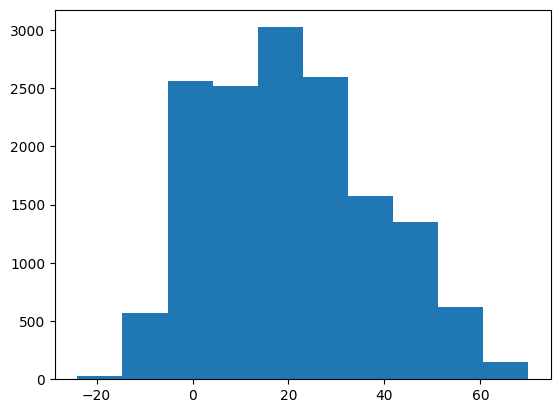

In [93]:
plt.hist(results["Basic"])

(array([  77.,  731., 1071., 1134.,  842.,  524.,  407.,  158.,   13.,
          43.]),
 array([-16.,  -6.,   4.,  14.,  24.,  34.,  44.,  54.,  64.,  74.,  84.]),
 <BarContainer object of 10 artists>)

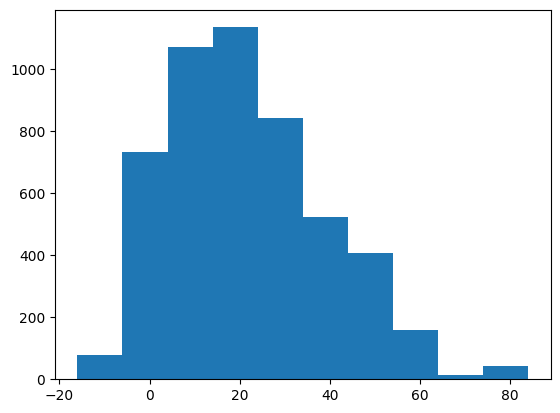

In [94]:
plt.hist(results["excercise 6"])

In [95]:
np.mean(results["Basic"])

np.float64(20.526533333333333)

In [96]:
np.mean(results["excercise 6"])

np.float64(20.3852)

In [97]:
np.std(results["Basic"])

np.float64(17.202025926681493)

In [98]:
np.std(results["excercise 6"])

np.float64(17.211659448176402)

In [99]:
# basic
## I was stuck here and used chatgpt. 
## I just had w/total, l/total

for name in results:
    win = 0
    loss = 0

    for w in results["Basic"]:
        if w> 0:
            win += 1
        else:
            loss += 1

    total = len(results["Basic"])

    print(" P(win):", win/total)
    print(" P(loss):", loss/total)

 P(win): 0.8768
 P(loss): 0.1232
 P(win): 0.8768
 P(loss): 0.1232


In [100]:
# excercise 6 
for name in results:
    win = 0
    loss = 0

    for w in results["excercise 6"]:
        if w> 0:
            win += 1
        else:
            loss += 1

    total = len(results["excercise 6"])

    print(" P(win):", win/total)
    print(" P(loss):", loss/total)

 P(win): 0.8844
 P(loss): 0.1156
 P(win): 0.8844
 P(loss): 0.1156


9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

In [108]:
## I changed the threshhold and ran it, looking at the probability. 
# threshold: -2

class Strategy:
    def always_hit(self, hand_value, dealer_card):
        return "hit"

    def always_fold(self, hand_value, dealer_card):
        return "fold"

    def basic_strat(self, hand_value, dealer_card):
        return "hit" if hand_value < 17 else "fold"

    def excercise_six_strat(self, hand_value, dealer_card):
        strat_specific_card_value = 0

        for card in seen_cards:
            rank = card.rank

            if rank in ['2', '3', '4', '5', '6']:
                strat_value += 1
            elif rank in ['7', '8', '9']:
                strat_value += 0
            else:
                strat_value -= 1

        if strat_value < -2:
            return "hit"
        else:
            return "fold"

strategy = Strategy()

simulations = 100
rounds = 50

starting_chips = 100

results = {
    "Basic":[], 
    "excercise 6":[]}

for sim in range(simulations):
    
    deck = Deck(6)
    deck.shuffle()
    deck.insert_plastic_card_randomly()


    players = [ Player("Basic", strategy.basic_strat),
      Player("Basic", strategy.basic_strat),
      Player("Basic", strategy.basic_strat), 
                Player("excercise 6", strategy.excercise_six_strat)]

    dealer = Dealer()
    game = Game(deck, players, dealer)


    for i in range(rounds):
        game.start_game()

        # got help from chatgpt. didn't understand how to express it
        # print each player's hand and chip
        for p in players:

            winnings = p.chips.balance - starting_chips
            results["excercise 6"].append(winnings)


for name in results:
    win = 0
    loss = 0

    for w in results["excercise 6"]:
        if w> 0:
            win += 1
        else:
            loss += 1

    total = len(results["excercise 6"])

    print(" P(win):", win/total)
    print(" P(loss):", loss/total)

# P(win): 0.8928
# P(loss): 0.1072

Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic ca

In [109]:
## I changed the threshhold and ran it, looking at the probability. 
# threshold: -4

class Strategy:
    def always_hit(self, hand_value, dealer_card):
        return "hit"

    def always_fold(self, hand_value, dealer_card):
        return "fold"

    def basic_strat(self, hand_value, dealer_card):
        return "hit" if hand_value < 17 else "fold"

    def excercise_six_strat(self, hand_value, dealer_card):
        strat_specific_card_value = 0

        for card in seen_cards:
            rank = card.rank

            if rank in ['2', '3', '4', '5', '6']:
                strat_value += 1
            elif rank in ['7', '8', '9']:
                strat_value += 0
            else:
                strat_value -= 1

        if strat_value < -4:
            return "hit"
        else:
            return "fold"

strategy = Strategy()

simulations = 100
rounds = 50

starting_chips = 100

results = {
    "Basic":[], 
    "excercise 6":[]}

for sim in range(simulations):
    
    deck = Deck(6)
    deck.shuffle()
    deck.insert_plastic_card_randomly()


    players = [ Player("Basic", strategy.basic_strat),
      Player("Basic", strategy.basic_strat),
      Player("Basic", strategy.basic_strat), 
                Player("excercise 6", strategy.excercise_six_strat)]

    dealer = Dealer()
    game = Game(deck, players, dealer)


    for i in range(rounds):
        game.start_game()

        # got help from chatgpt. didn't understand how to express it
        # print each player's hand and chip
        for p in players:

            winnings = p.chips.balance - starting_chips
            results["excercise 6"].append(winnings)


for name in results:
    win = 0
    loss = 0

    for w in results["excercise 6"]:
        if w> 0:
            win += 1
        else:
            loss += 1

    total = len(results["excercise 6"])

    print(" P(win):", win/total)
    print(" P(loss):", loss/total)

# P(win): 0.89765
# P(loss): 0.10235

Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic ca

In [110]:
## I changed the threshhold and ran it, looking at the probability. 
# threshold: -6 

class Strategy:
    def always_hit(self, hand_value, dealer_card):
        return "hit"

    def always_fold(self, hand_value, dealer_card):
        return "fold"

    def basic_strat(self, hand_value, dealer_card):
        return "hit" if hand_value < 17 else "fold"

    def excercise_six_strat(self, hand_value, dealer_card):
        strat_specific_card_value = 0

        for card in seen_cards:
            rank = card.rank

            if rank in ['2', '3', '4', '5', '6']:
                strat_value += 1
            elif rank in ['7', '8', '9']:
                strat_value += 0
            else:
                strat_value -= 1

        if strat_value < -6:
            return "hit"
        else:
            return "fold"

strategy = Strategy()

simulations = 100
rounds = 50

starting_chips = 100

results = {
    "Basic":[], 
    "excercise 6":[]}

for sim in range(simulations):
    
    deck = Deck(6)
    deck.shuffle()
    deck.insert_plastic_card_randomly()


    players = [ Player("Basic", strategy.basic_strat),
      Player("Basic", strategy.basic_strat),
      Player("Basic", strategy.basic_strat), 
                Player("excercise 6", strategy.excercise_six_strat)]

    dealer = Dealer()
    game = Game(deck, players, dealer)


    for i in range(rounds):
        game.start_game()

        # got help from chatgpt. didn't understand how to express it
        # print each player's hand and chip
        for p in players:

            winnings = p.chips.balance - starting_chips
            results["excercise 6"].append(winnings)


for name in results:
    win = 0
    loss = 0

    for w in results["excercise 6"]:
        if w> 0:
            win += 1
        else:
            loss += 1

    total = len(results["excercise 6"])

    print(" P(win):", win/total)
    print(" P(loss):", loss/total)

# P(win): 0.899
# P(loss): 0.101

Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic ca

In [111]:
## I changed the threshhold and ran it, looking at the probability. 
# threshold: 2 fold 

class Strategy:
    def always_hit(self, hand_value, dealer_card):
        return "hit"

    def always_fold(self, hand_value, dealer_card):
        return "fold"

    def basic_strat(self, hand_value, dealer_card):
        return "hit" if hand_value < 17 else "fold"

    def excercise_six_strat(self, hand_value, dealer_card):
        strat_specific_card_value = 0

        for card in seen_cards:
            rank = card.rank

            if rank in ['2', '3', '4', '5', '6']:
                strat_value += 1
            elif rank in ['7', '8', '9']:
                strat_value += 0
            else:
                strat_value -= 1

        if strat_value > 2:
            return "fold"
        else:
            return "hit"

strategy = Strategy()

simulations = 100
rounds = 50

starting_chips = 100

results = {
    "Basic":[], 
    "excercise 6":[]}

for sim in range(simulations):
    
    deck = Deck(6)
    deck.shuffle()
    deck.insert_plastic_card_randomly()


    players = [ Player("Basic", strategy.basic_strat),
      Player("Basic", strategy.basic_strat),
      Player("Basic", strategy.basic_strat), 
                Player("excercise 6", strategy.excercise_six_strat)]

    dealer = Dealer()
    game = Game(deck, players, dealer)


    for i in range(rounds):
        game.start_game()

        # got help from chatgpt. didn't understand how to express it
        # print each player's hand and chip
        for p in players:

            winnings = p.chips.balance - starting_chips
            results["excercise 6"].append(winnings)


for name in results:
    win = 0
    loss = 0

    for w in results["excercise 6"]:
        if w> 0:
            win += 1
        else:
            loss += 1

    total = len(results["excercise 6"])

    print(" P(win):", win/total)
    print(" P(loss):", loss/total)

# P(win): 0.89955
# P(loss): 0.10045

Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic ca

In [112]:
## I changed the threshhold and ran it, looking at the probability. 
# threshold: 6 fold 

class Strategy:
    def always_hit(self, hand_value, dealer_card):
        return "hit"

    def always_fold(self, hand_value, dealer_card):
        return "fold"

    def basic_strat(self, hand_value, dealer_card):
        return "hit" if hand_value < 17 else "fold"

    def excercise_six_strat(self, hand_value, dealer_card):
        strat_specific_card_value = 0

        for card in seen_cards:
            rank = card.rank

            if rank in ['2', '3', '4', '5', '6']:
                strat_value += 1
            elif rank in ['7', '8', '9']:
                strat_value += 0
            else:
                strat_value -= 1

        if strat_value > 6:
            return "fold"
        else:
            return "hit"

strategy = Strategy()

simulations = 100
rounds = 50

starting_chips = 100

results = {
    "Basic":[], 
    "excercise 6":[]}

for sim in range(simulations):
    
    deck = Deck(6)
    deck.shuffle()
    deck.insert_plastic_card_randomly()


    players = [ Player("Basic", strategy.basic_strat),
      Player("Basic", strategy.basic_strat),
      Player("Basic", strategy.basic_strat), 
                Player("excercise 6", strategy.excercise_six_strat)]

    dealer = Dealer()
    game = Game(deck, players, dealer)


    for i in range(rounds):
        game.start_game()

        # got help from chatgpt. didn't understand how to express it
        # print each player's hand and chip
        for p in players:

            winnings = p.chips.balance - starting_chips
            results["excercise 6"].append(winnings)


for name in results:
    win = 0
    loss = 0

    for w in results["excercise 6"]:
        if w> 0:
            win += 1
        else:
            loss += 1

    total = len(results["excercise 6"])

    print(" P(win):", win/total)
    print(" P(loss):", loss/total)

# P(win): 0.8664
# P(loss): 0.1336

Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic ca

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings.

- Always fold if hand_value > 20

In [115]:

class Strategy:
    def always_hit(self, hand_value, dealer_card):
        return "hit"

    def always_fold(self, hand_value, dealer_card):
        return "fold"

    def basic_strat(self, hand_value, dealer_card):
        return "hit" if hand_value < 17 else "fold"

    def fold_at_certain(self, hand_value, dealer_card):
        return "fold" if hand_value > 12 else "hit"


    def excercise_six_strat(self, hand_value, dealer_card):
        strat_specific_card_value = 0

        for card in seen_cards:
            rank = card.rank

            if rank in ['2', '3', '4', '5', '6']:
                strat_value += 1
            elif rank in ['7', '8', '9']:
                strat_value += 0
            else:
                strat_value -= 1

        if strat_value > 6:
            return "fold"
        else:
            return "hit"

strategy = Strategy()

simulations = 100
rounds = 50

starting_chips = 100

results = {
    "Basic":[], 
    "new strat":[]}

for sim in range(simulations):
    
    deck = Deck(6)
    deck.shuffle()
    deck.insert_plastic_card_randomly()


    players = [ Player("Basic", strategy.basic_strat),
      Player("Basic", strategy.basic_strat),
      Player("Basic", strategy.basic_strat), 
                Player("new strat", strategy.fold_at_certain)]

    dealer = Dealer()
    game = Game(deck, players, dealer)


    for i in range(rounds):
        game.start_game()

        # got help from chatgpt. didn't understand how to express it
        # print each player's hand and chip
        for p in players:

            winnings = p.chips.balance - starting_chips
            results["new strat"].append(winnings)


for name in results:
    win = 0
    loss = 0

    for w in results["new strat"]:
        if w> 0:
            win += 1
        else:
            loss += 1

    total = len(results["new strat"])

    print(" P(win):", win/total)
    print(" P(loss):", loss/total)

Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic card. Shuffling deck.
Plastic ca

In [ ]:
## It shows a similar results as the other strategies (strategy 6) 

Solution Given in Lecture:

In [24]:
## given solution

class base:
    SILENT = 6
    DEBUG = 1
    INFO =2
    WARNING = 3
    ERROR = 4
    CRITICAL = 5

    def __init__(self, level = 0):
        self.level = level

    def message(self, level, *args):
        if level >= self.level:
            print(*args)


class Card(base):
    __suits = ["Clubs", "Diamonds", "Hearts", "Spades", "ShuffleCard"]
    __values = list(range(2,11)) + ["Jack", "Queen", "King", "Ace"]

    def __init__(self, suit, value=None):
        base.__init__(self)
        self.__suit = suit if suit in self.__suits else None
        self.__value = value if value in self.__values else None

        if self.__suit is None:
            self.message(self.ERROR, "Error, bad suit:", suit)

        if self.__value is None and self.__suit != "ShuffleCard":
            self.message(self.ERROR, "Error, bad value:", value)

    ## similar to what I originally had
    def value(self):
        return self.__value

    def suit(self):
        return self.__suit

    def numerical_value(self):
        if self.__value == "Ace":
            return 1
        elif self.__value in ["Jack", "Queen", "King"]:
            return 10
        else:
            return self.__value

    def shuffle_card(self):
        return self.__suit == "ShuffleCard"

    def __str__(self):
        if self.shuffle_card():
            return "Shuffle Card"
        else:
            return str(self.__value) + " of " + self.__suit

    __repr__ = __str__

In [25]:
import random

class Deck(base):
    __suits = ["Clubs", "Diamonds", "Hearts", "Spades"]
    __values = list(range(2,11)) + ["Jack", "Queen", "King", "Ace"]

    def __init__(self, n_decks = 6):
        base.__init__(self)
        self.__n_decks = n_decks

        self.__cards = list()

        for i in range(self.__n_decks):
            self.__cards.extend(self.__make_deck())

        self.__cards.append(Card("ShuffleCard"))
        ## logic to add shuffle card modified from my code
        shuffle_card = Card("ShuffleCard")
        position = random.randint(0, len(self.__cards))
        self.__cards.insert(position, shuffle_card)

    def __make_deck(self):
        deck = list()
        for suit in self.__suits:
            for value in self.__values:
                deck.append(Card(suit, value))
            return deck

    def shuffle(self):
        random.shuffle(self.__cards)

    def deal(self):
        if len(self.__cards)>0:
            return self.__cards.pop()
        else:
            for i in range(self.__n_decks):
                self.__cards.extend(self.__make_deck())
            self.shuffle()
            return self.__cards.pop()

In [26]:
my_deck = Deck()
my_deck.shuffle()

[my_deck.deal() for i in range(10)]

[9 of Clubs,
 3 of Clubs,
 Jack of Clubs,
 5 of Clubs,
 Queen of Clubs,
 6 of Clubs,
 7 of Clubs,
 6 of Clubs,
 8 of Clubs,
 10 of Clubs]

In [27]:
## given solution

def calc_hand_value(hand):
    card_values = list(map(lambda card: card.numerical_value(),hand))

    n_As = len(list(filter(lambda x: x==1, card_values)))

    hand_value = sum(card_values)

    if n_As ==0:
        return hand_value

    ## Case the last Ace is 1
    Ace_as_one = hand_value
    Ace_as_eleven = hand_value+10

    if Ace_as_eleven<=21:
        return Ace_as_eleven
    else:
        return Ace_as_one

               

In [28]:
calc_hand_value( [Card("Clubs", 10), Card("Clubs", 2), Card("Heart", 9)])

Error, bad suit: Heart


21

In [29]:
calc_hand_value( [Card("Clubs", 10), Card("Clubs", 2), Card("Hearts", 9)])

21

In [30]:
calc_hand_value( [Card("Clubs", 10), Card("Clubs", 2), Card("Hearts", "Ace")])

13

In [31]:
## given solution
class PlayerBase(base):
    def __init__(self, name, n_chips):
        base.__init__(self)
        self.__name = name
        self.__n_chips = n_chips

    def name(self):
        return self.__name

    def chips(self):
        return self.__n_chips

    def pay(self, value=2):
        self.__n_chips += value

    def deduct(self, value=2):
        self.__n_chips += value

    def play_hand(self, down_card, up_cards, seen_cards):
        raise NotImplementedError

    def __str__(self):
        return self.__name + "("+str(self.__n_chips)+ ")"

        __repr__ = __str__

class DealerPlayer(PlayerBase):
    def __init__(self, threshold=16):
        self.__threshold = threshold
        PlayerBase.__init__(self, "Mr. Dealer", 1000)

    def play_hand(self, down_card, up_cards, seen_cards):
        print("Down Card:" , down_card)
        print("Up Cards:" , up_cards)
        print("Seen cards:" , seen_cards)
        hit_str = input("Hit(Y/N):")
        return hit_str.upper() == "Y"

class Strategy_1_Player(PlayerBase):
    def play_hand(self, down_card, up_cards, seen_cards):
        return True
    

In [32]:
## given solution
class Game(base):
    def __init__(self, n_decks=6):
        base.__init__(self,self.INFO)
        self.__n_decks = n_decks
        self.__players = list()
        self.__all_players = list()

        self.__shuffle = False

    def players(self):
        return self.__players

    def all_players(self):
        return self.__all_players

    def add_player(self,player):
        self.__players.append(player)
        self.__all_players.append(player)

    def deal_and_check_shuffle(self, deck):
        card = deck.deal()
        if card.shuffle_card():
            shuffle = True
            card = deck.deal()
        return card

    def show_status(self, hands, seen_cards):
        self.message(self.INFO, "--------------------------------")
        self.message(self.INFO, "Hands:" , hands)
        self.message(self.INFO, "Seen Cards:" , seen_cards)
        self.message(self.INFO,"******************************************************")
        self.message(self.INFO, "Players:")
        self.message(self.INFO, "*****************************************************")
        for i,player in enumerate(self.__all_players):
            self.message(self.INFO, i, ":",player)
        self.message(self.INFO,"------------------------------------------------------------------------------")

    def play_game(self,n_hands):
        self.add_player(DealerPlayer())

        deck = None
        self.__shuffle = False

        # check if all player has chips

        for i_hand in range(n_hands):

            self.__players = list(filter(lambda player: player.chips()>=2, self.__players))
            self.message(self.DEBUG,"n players , n all players", len(self.__players), len(self.__all_players))
            self.message(self.DEBUG, "Starting Hand:",i_hand, "/",n_hands)

            # do we have deck or have to shuffle?
            if deck is None or self.__shuffle:
                self.message(self.DEBUG, "Creating New Deck / Shuffling")
                deck = Deck()
                deck.shuffle()
                seen_cards = list()
                self.__shuffle = False

            hands = list()

            # Deal each players hand
            # down card deal
            self.message(self.DEBUG, "Dealing Cards")
            for player_i, player in enumerate(self.__players):
                down_card = self.deal_and_check_shuffle(deck)
                up_cards = list()
                hands.append((down_card, up_cards))
                if player_i < len(self.__players)-1:
                    seen_cards.append(down_card)

            #up card deal
            for (down_card, up_cards) in hands:
                up_cards.append(self.deal_and_check_shuffle(deck))
                seen_cards.append(up_cards[-1])

            self.show_status(hands, seen_cards)

            # play

            for player_i, ((down_card, up_cards), player) in enumerate(zip(hands,self.__players)):
                self.message(self.DEBUG, "Asking Player", player_i, "to Play")
                self.message(self.DEBUG,"Player", player_i, "hand total:", calc_hand_value([down_card]+up_cards))
                hit = True
                this_hand_up_cards = list()
                while(hit):
                    hit = player.play_hand(down_card, up_cards, seen_cards)

                    if hit:
                        self.message(self.DEBUG,"Player:", player_i, "Hit")
                        card = self.deal_and_check_shuffle(deck)
                        up_cards.append(card)
                        this_hand_up_cards.append(card)
                        hand_value = calc_hand_value([down_card] + up_cards)
                        self.message(self.DEBUG,"Hand Value:",hand_value)
                        if hand_value < 21:
                            hit = True
                        else:
                            hit = False
                            if hand_value > 21:
                                self.message(self.DEBUG, "Player", player_i, "Busted")
                            else:
                                self.message(self.DEBUG, "Player", player_i, "Got 21")
                    else:
                        self.message(self.DEBUG, "Player",player_i, "Stay")

                seen_cards.append(down_card)
                seen_cards.extend(this_hand_up_cards)

                #pay
            hand_values = (calc_hand_value([hand[0]]+hand[1]) for hand in hands)

            self.message(self.DEBUG,"Hand Value:",hand_values)

#Determine who gets paid
            if hand_values[-1] == 21:
                self.message(self.DEBUG, "Dealer Got 21")
                for player_i,(hand_value, player) in enumerate(zip(hand_values[:-1],self.__players[:-1])):
                    if hand_value == 21:
                        self.message(self.DEBUG, "Player", player_i, "Got 21. Paying 3 chips")
                        player.pay(3)
                    else:
                        self.message(self.DEBUG, "Player",player_i, "Busted or dealer won. Deducting 2 chips")
                        player.deduct(2)

            if hand_values[-1] > 21:
                self.message(self.DEBUG, "Dealer Busted")
                for player_i,(hand_value, player) in enumerate(zip(hand_values[:-1],self.__players[:-1])):
                    if hand_value == 21:
                        self.message(self.DEBUG, "Player", player_i, "Got 21. Paying 3 chips")
                        player.pay(3)
                    elif hand_value>21:
                        self.message(self.DEBUG, "Player", player_i, "Busted. Deducting 2 chips.")
                        player.deduct(2)
                    else:
                        self.message(self.DEBUG, "Player",player_i, "paying 2 chips")
                        player.pay(2)            
                        
            if hand_values[-1] < 21:
                self.message(self.DEBUG, "Dealer hand is:",hand_values[-1])
                for player_i,(hand_value, player) in enumerate(zip(hand_values[:-1],self.__players[:-1])):
                    if hand_value == 21:
                        self.message(self.DEBUG, "Player", player_i, "Got 21. Paying 3 chips")
                        player.pay(3)
                    elif hand_value>21:
                        self.message(self.DEBUG, "Player", player_i, "Busted. Deducting 2 chips.")
                        player.deduct(2)
                    elif hand_value > hand_values[-1]:
                        self.message(self.DEBUG, "Player", player_i," hand was", hand_value, "versus Dealer hand", hand_values [-1], "Paying 2 chips.")
                        player.pay(2)
                    else:
                        self.message(self.DEBUG, "Player",player_i, "hand was", hand_value, "versus Dealer hand", hand_values[-1], "Deducting 2 chips")
                        player.deduct(2)            

In [33]:
my_game=Game()
my_game.level=Game.DEBUG

my_game.add_player(Strategy_1_Player("Dummy player", 100))
my_game.add_player(ConsolePlayer("ME!", 100))

my_game.play_game(2)

NameError: name 'ConsolePlayer' is not defined